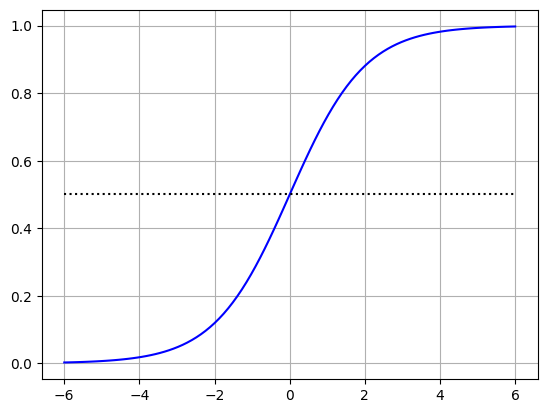

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

x = np.linspace(-6, 6, 100)
plt.plot(x, sigmoid(x), 'b-', label='Probability')

plt.hlines([0.5], -6, 6, 'k', 'dotted', label='Threshold')
plt.grid(True)
plt.show()

In [24]:
X = np.array([
    [170, 25, 1],
    [180, 30, 1],
    [200, 35, 1]
])
y = np.array([0, 0, 1])
theta = np.array([0.3, -0.4, -43.])

z = X @ theta
h = sigmoid(z)

y_pred = (h >= 0.5).astype(int)
y_pred

def compute_cost(X, y, theta):
    m = len(y)
    
    z = X @ theta
    h = sigmoid(z)
    
    # avoid log(0)
    epsilon = 1e-15
    h = np.clip(h, epsilon, 1 - epsilon)
    
    cost = -(1/m) * np.sum(
        y * np.log(h) + (1 - y) * np.log(1 - h)
    )
    
    return cost

cost = compute_cost(X, y, theta)

y_pred, cost

(array([0, 0, 1]), np.float64(0.1629256833783124))

### Gradient for Gradient Descent

$$
\nabla J(\theta) = \frac{1}{m} X^T \left( \sigma(X\theta) - y \right)
$$

In [25]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris(as_frame=True)

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target_names[iris.target] == 'virginica').astype(int)[:, np.newaxis]
#y = (iris.target == 2).astype(int).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123)

In [26]:
from sklearn.preprocessing import add_dummy_feature

X_train_dummy = add_dummy_feature(X_train)
X_train_dummy

array([[1. , 1.3, 0.4],
       [1. , 3.9, 1.2],
       [1. , 3.5, 1. ],
       [1. , 1.2, 0.2],
       [1. , 5.9, 2.3],
       [1. , 5.2, 2.3],
       [1. , 5.1, 1.9],
       [1. , 5.1, 2.4],
       [1. , 5.6, 2.4],
       [1. , 4. , 1.3],
       [1. , 1.5, 0.3],
       [1. , 1.3, 0.2],
       [1. , 5.1, 2. ],
       [1. , 1.7, 0.5],
       [1. , 1.5, 0.1],
       [1. , 4.7, 1.5],
       [1. , 4.6, 1.4],
       [1. , 4. , 1.3],
       [1. , 3.5, 1. ],
       [1. , 5.1, 1.9],
       [1. , 4.4, 1.4],
       [1. , 5.3, 2.3],
       [1. , 1.3, 0.3],
       [1. , 5.7, 2.1],
       [1. , 4.2, 1.2],
       [1. , 1.5, 0.4],
       [1. , 1.6, 0.2],
       [1. , 5.6, 1.8],
       [1. , 4.3, 1.3],
       [1. , 6.7, 2. ],
       [1. , 6.9, 2.3],
       [1. , 1.9, 0.4],
       [1. , 4.5, 1.5],
       [1. , 3.7, 1. ],
       [1. , 5.1, 1.8],
       [1. , 1.4, 0.1],
       [1. , 5.8, 1.6],
       [1. , 4.7, 1.6],
       [1. , 4.7, 1.4],
       [1. , 1.6, 0.2],
       [1. , 5.6, 2.1],
       [1. , 5. 

In [27]:
eta = 0.1
n_epochs = 3000
m = len(X_train_dummy)

rng = np.random.default_rng(123)
theta = rng.standard_normal((3, 1))

for epoch in range(n_epochs):
    z = X_train_dummy @ theta
    h = sigmoid(z)
    gradients = 1 / m * X_train_dummy.T @ (h - y_train)
    theta = theta - eta * gradients

theta

array([[-8.3833218 ],
       [ 0.12507303],
       [ 4.65472703]])

In [28]:
X_test_dummy = add_dummy_feature(X_test)

z_test = X_test_dummy @ theta
h_test = sigmoid(z_test)
h_test.round(2)

array([[0.31],
       [0.89],
       [0.93],
       [0.14],
       [0.  ],
       [0.64],
       [0.14],
       [0.  ],
       [0.  ],
       [0.1 ],
       [0.95],
       [0.  ],
       [0.2 ],
       [0.66],
       [0.96],
       [0.93],
       [0.  ],
       [0.  ],
       [0.22],
       [0.  ],
       [0.  ],
       [0.32],
       [0.  ],
       [0.65],
       [0.  ],
       [0.  ],
       [0.  ],
       [0.82],
       [0.94],
       [0.  ],
       [0.77],
       [0.32],
       [0.  ],
       [0.  ],
       [0.04],
       [0.04],
       [0.85],
       [0.  ]])

In [29]:
y_test_pred = np.where(h_test >= 0.5, 1, 0)
y_test_pred

array([[0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0]])

In [30]:
(y_test_pred == y_test).sum(), len(y_test)

(np.int64(36), 38)

In [31]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train.ravel())
log_reg.intercept_, log_reg.coef_

(array([-16.52619144]), array([[2.59294033, 2.1855874 ]]))

In [32]:
log_reg.predict_proba(X_test).round(2)

array([[0.63, 0.37],
       [0.09, 0.91],
       [0.06, 0.94],
       [0.95, 0.05],
       [1.  , 0.  ],
       [0.54, 0.46],
       [0.91, 0.09],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.92, 0.08],
       [0.15, 0.85],
       [1.  , 0.  ],
       [0.97, 0.03],
       [0.16, 0.84],
       [0.01, 0.99],
       [0.03, 0.97],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.78, 0.22],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.51, 0.49],
       [1.  , 0.  ],
       [0.47, 0.53],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.37, 0.63],
       [0.  , 1.  ],
       [1.  , 0.  ],
       [0.03, 0.97],
       [0.57, 0.43],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.98, 0.02],
       [1.  , 0.  ],
       [0.01, 0.99],
       [1.  , 0.  ]])

In [33]:
log_reg.predict(X_test)

array([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0])

In [34]:
(log_reg.predict(X_test) == y_test.ravel()).sum(), len(y_test)

(np.int64(35), 38)

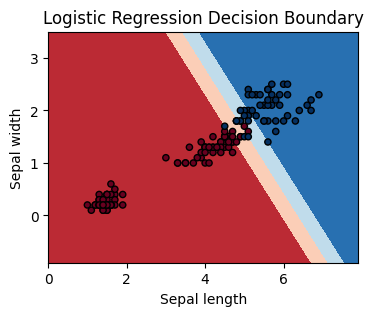

In [35]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 3))
DecisionBoundaryDisplay.from_estimator(
    log_reg,
    X,
    cmap=plt.cm.RdBu,
    ax=ax,
    response_method='predict_proba',
    plot_method='contourf',
    #levels = [-1, 0, 0.5, 1, 2]
    #levels = [0, 0.5, 1]
    levels = np.linspace(0, 1, 5)
)

ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolors='k', s=20)
ax.set_xlabel("Sepal length")
ax.set_ylabel("Sepal width")
ax.set_title("Logistic Regression Decision Boundary")
plt.show()

In [36]:
def softmax(Z):
    return np.exp(Z) / np.sum(np.exp(Z), axis=1, keepdims=True)

In [43]:
def softmax(Z):
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z_shifted)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

In [38]:
x = np.array([
    [1. , 5.4, 3.9, 1.3, 0.4],
    [1. , 5.8, 2.7, 3.9, 1.2]
    ])
th = np.array([
	[ 0.30471708, -1.03998411,  0.7504512 ],
	[ 0.94056472, -1.95103519, -1.30217951],
	[ 0.1278404 , -0.31624259, -0.01680116],
	[-0.85304393,  0.87939797,  0.77779194],
	[ 0.0660307 ,  1.12724121,  0.46750934]
])

z = x@th
softmax(z).round(3)

array([[1.   , 0.   , 0.   ],
       [0.998, 0.   , 0.002]])

In [45]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

iris = load_iris(as_frame=True)

X = iris.data.values
y = iris.target.values

encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y.reshape(-1, 1))
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123)

In [46]:
X_train[:5], y_train[:5]

(array([[5.4, 3.9, 1.3, 0.4],
        [5.8, 2.7, 3.9, 1.2],
        [5. , 2. , 3.5, 1. ],
        [5. , 3.2, 1.2, 0.2],
        [6.8, 3.2, 5.9, 2.3]]),
 array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.]]))

In [47]:
from sklearn.preprocessing import add_dummy_feature

X_train_b = add_dummy_feature(X_train)
X_train_b[:5]

array([[1. , 5.4, 3.9, 1.3, 0.4],
       [1. , 5.8, 2.7, 3.9, 1.2],
       [1. , 5. , 2. , 3.5, 1. ],
       [1. , 5. , 3.2, 1.2, 0.2],
       [1. , 6.8, 3.2, 5.9, 2.3]])

In [49]:
eta = 0.1
n_epochs = 30000

m, n = X_train_b.shape
n_classes = 3

rng = np.random.default_rng(seed=42)
Theta = rng.standard_normal((n, n_classes)) 

for epoch in range(n_epochs):
    Z = X_train_b @ Theta
    H = softmax(Z)
    gradients = 1 / m * X_train_b.T @ (H - y_train)
    Theta = Theta - eta * gradients 

Theta

array([[ 0.92960163,  4.86596243, -5.78037989],
       [ 1.91174845, -0.53232328, -3.69207515],
       [ 3.83444799,  1.00462981, -5.04428115],
       [-6.29105171,  0.5229482 ,  6.5722495 ],
       [-2.54571706, -3.12554831,  7.33204661]])

In [ ]:
X_test_b = add_dummy_feature(X_test)
Z_test = X_test_b @ Theta
H_test = softmax(Z_test).round(2)
np.argmax(H_test, axis=1) == np.argmax(y_test, axis=1)

### Sklearn

In [52]:
X = iris.data.values
y = iris.target.values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123)

softmax_reg = LogisticRegression()
softmax_reg.fit(X_train, y_train)
softmax_reg.intercept_, softmax_reg.coef_

(array([  9.58860043,   1.87493514, -11.46353557]),
 array([[-0.44761016,  0.8679296 , -2.35836567, -0.98974547],
        [ 0.51526121, -0.24634847, -0.18000151, -0.87022088],
        [-0.06765106, -0.62158113,  2.53836718,  1.85996635]]))

In [53]:
y_pred = softmax_reg.predict(X_test)
y_pred

array([1, 2, 2, 1, 0, 2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 0, 1,
       0, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 1, 1, 2, 0])

In [54]:
y_pred == y_test

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])